In [1]:
# Basic Inception
import pandas as pd

df = pd.read_csv("healthcare.csv")

df.shape
df.columns
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rndrng_NPI                     3266 non-null   int64  
 1   Rndrng_Prvdr_Last_Org_Name     3266 non-null   object 
 2   Rndrng_Prvdr_First_Name        3093 non-null   object 
 3   Rndrng_Prvdr_MI                2124 non-null   object 
 4   Rndrng_Prvdr_Crdntls           2929 non-null   object 
 5   Rndrng_Prvdr_Gndr              3093 non-null   object 
 6   Rndrng_Prvdr_Ent_Cd            3266 non-null   object 
 7   Rndrng_Prvdr_St1               3266 non-null   object 
 8   Rndrng_Prvdr_St2               835 non-null    object 
 9   Rndrng_Prvdr_City              3266 non-null   object 
 10  Rndrng_Prvdr_State_Abrvtn      3266 non-null   object 
 11  Rndrng_Prvdr_State_FIPS        3266 non-null   object 
 12  Rndrng_Prvdr_Zip5              3266 non-null   i

In [2]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['rndrng_npi', 'rndrng_prvdr_last_org_name', 'rndrng_prvdr_first_name',
       'rndrng_prvdr_mi', 'rndrng_prvdr_crdntls', 'rndrng_prvdr_gndr',
       'rndrng_prvdr_ent_cd', 'rndrng_prvdr_st1', 'rndrng_prvdr_st2',
       'rndrng_prvdr_city', 'rndrng_prvdr_state_abrvtn',
       'rndrng_prvdr_state_fips', 'rndrng_prvdr_zip5', 'rndrng_prvdr_ruca',
       'rndrng_prvdr_ruca_desc', 'rndrng_prvdr_cntry', 'rndrng_prvdr_type',
       'rndrng_prvdr_mdcr_prtcptg_ind', 'hcpcs_cd', 'hcpcs_desc',
       'hcpcs_drug_ind', 'place_of_srvc', 'tot_benes', 'tot_srvcs',
       'tot_bene_day_srvcs', 'avg_sbmtd_chrg', 'avg_mdcr_alowd_amt',
       'avg_mdcr_pymt_amt', 'avg_mdcr_stdzd_amt'],
      dtype='object')

In [3]:
df = df[[
    'rndrng_npi',
    'rndrng_prvdr_city',
    'rndrng_prvdr_state_abrvtn',
    'rndrng_prvdr_type',
    'avg_mdcr_alowd_amt',
    'avg_mdcr_pymt_amt',
    'avg_mdcr_stdzd_amt',
    'tot_benes',
    'tot_bene_day_srvcs'
]]

In [4]:
df.isnull().sum()

df = df.dropna()

In [5]:
# Convert to Numeric
cols = [
    'avg_mdcr_alowd_amt',
    'avg_mdcr_pymt_amt',
    'avg_mdcr_stdzd_amt',
    'tot_benes',
    'tot_bene_day_srvcs'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

In [6]:
df.describe()

,rndrng_npi,avg_mdcr_alowd_amt,avg_mdcr_pymt_amt,avg_mdcr_stdzd_amt,tot_benes,tot_bene_day_srvcs
count,3.265000e+03,3265.000000,3265.000000,3265.000000,3265.000000,3265.000000
mean,1.498213e+09,110.965606,86.830896,86.033558,76.100766,114.964165
std,2.867227e+08,382.992403,305.547662,304.284708,465.485363,506.482659
min,1.003002e+09,0.010000,0.008610,0.008610,11.000000,11.000000
25%,1.245755e+09,27.419750,21.468333,19.809106,17.000000,20.000000
50%,1.497887e+09,69.062303,52.481818,53.177083,31.000000,39.000000
75%,1.740419e+09,120.198519,89.397600,89.033417,70.000000,101.000000
max,1.992978e+09,12647.319020,10087.180588,9596.060000,25822.000000,25864.000000


In [7]:
# Top Providers
top_providers = df.groupby('rndrng_npi')['avg_mdcr_pymt_amt'].sum().sort_values(ascending=False).head(10)
top_providers

rndrng_npi
1497783831    10087.180588
1790760478     9106.003500
1174165237     6527.826667
1841447745     4923.428461
1770519761     2994.951250
1396298139     2262.911600
1811262363     2175.141250
1659519684     1896.803846
1073691564     1300.683125
1811968688     1279.982308
Name: avg_mdcr_pymt_amt, dtype: float64

In [8]:
# Specialty Analysis
specialty = df.groupby('rndrng_prvdr_type')['avg_mdcr_pymt_amt'].sum().sort_values(ascending=False).head(10)
specialty

rndrng_prvdr_type
Ambulatory Surgical Center    23552.433640
Vascular Surgery              21457.269264
Internal Medicine             19106.452907
Orthopedic Surgery            18076.379839
Diagnostic Radiology          16359.390600
Family Practice               16297.975860
Nurse Practitioner            16137.895839
Cardiology                    10259.672354
Physician Assistant            9735.156938
Ophthalmology                  9436.048820
Name: avg_mdcr_pymt_amt, dtype: float64

In [9]:
# State- Wise Cost
state_cost = df.groupby('rndrng_prvdr_state_abrvtn')['avg_mdcr_pymt_amt'].sum().sort_values(ascending=False).head(10)
state_cost

rndrng_prvdr_state_abrvtn
CA    39658.976058
FL    27692.502833
NY    19759.731514
TX    18614.910551
IN    13612.070088
PA    13298.117158
IL    10226.858508
OH     9087.408762
GA     8234.816783
WA     7416.759432
Name: avg_mdcr_pymt_amt, dtype: float64

In [10]:
# Outlier Detection
threshold = df['avg_mdcr_pymt_amt'].quantile(0.99)

outliers = df[df['avg_mdcr_pymt_amt'] > threshold]

outliers[['rndrng_npi', 'rndrng_prvdr_type', 'avg_mdcr_pymt_amt']].head()

,rndrng_npi,rndrng_prvdr_type,avg_mdcr_pymt_amt
70,1659335438,Ambulatory Surgical Center,1082.506667
404,1720280662,Orthopedic Surgery,841.435333
428,1477685907,Dermatology,721.647143
460,1558334490,Orthopedic Surgery,1022.838628
570,1225252257,Ambulatory Surgical Center,827.259665


# Insight
Top 1% providers exhibit payments up to ~20× higher than the median, indicating extreme outliers and potential high-cost billing patterns.

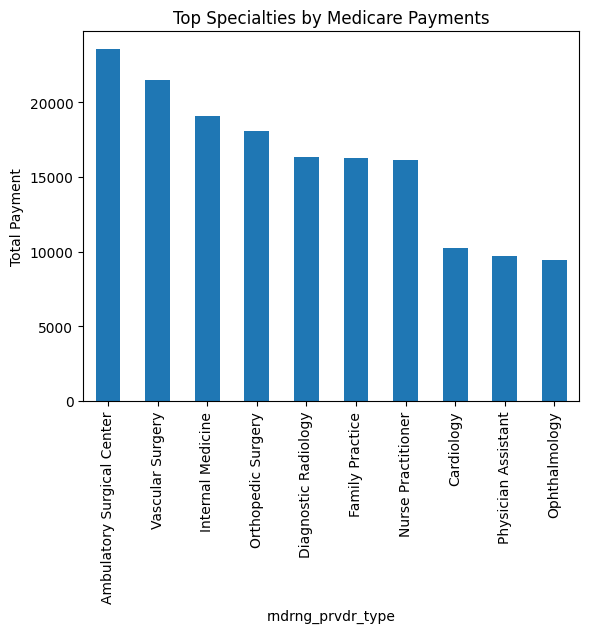

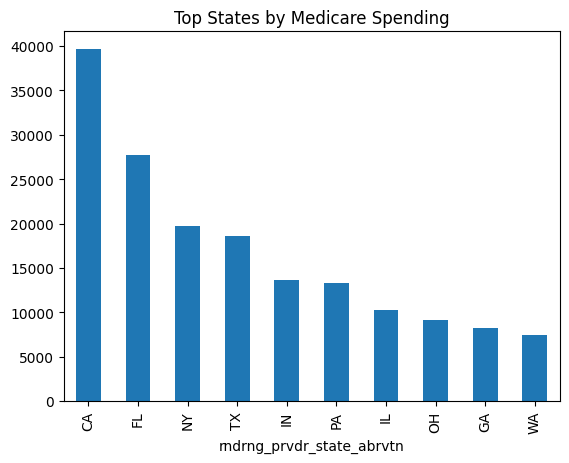

In [11]:
 # Visuals
import matplotlib.pyplot as plt

# Top specialties
specialty.plot(kind='bar')
plt.title("Top Specialties by Medicare Payments")
plt.ylabel("Total Payment")
plt.show()

# State analysis
state_cost.plot(kind='bar')
plt.title("Top States by Medicare Spending")
plt.show()

# Top Specialties Graph
Ambulatory Surgical Centers and surgical specialties dominate Medicare reimbursements, contributing the highest total payments among provider types.

# Top States Graph
Medicare spending is geographically concentrated, with California leading significantly (~40% higher than Florida), followed by Florida and New York.

In [12]:
df.to_csv("healthcare_cleaned.csv", index=False)

# Additional Insights

# Distribution Insight
Payment distribution is highly right-skewed, with mean (~86) significantly higher than median (~52), indicating a few high-value providers dominate reimbursements.

# Variability Insight
High standard deviation (~305) relative to mean suggests substantial variability in billing patterns across providers.

# Service vs Beneficiary Insight
Service counts exceed beneficiary counts, indicating repeated procedures per patient and cost driven by service intensity rather than patient volume.